In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

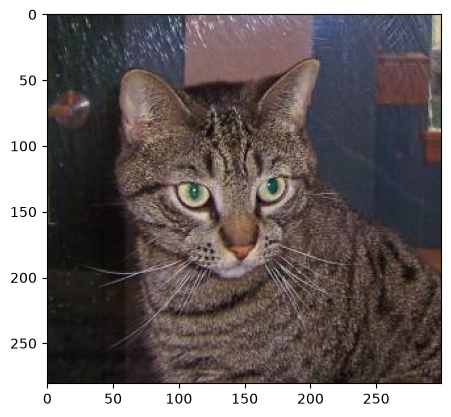

In [2]:
img = image.load_img('Dataset/train/Cat/1.JPG')
plt.imshow(img)

In [3]:
cv2.imread('Dataset/train/Cat/1.JPG').shape  #height, width, and channels of image

(281, 300, 3)

In [4]:
train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

validation = ImageDataGenerator(rescale=1/255)


In [5]:
train_dataset = train.flow_from_directory('Dataset/train/',
                                           target_size= (256,256),
                                           classes=['Cat', 'Dog', 'Elephant', 'Horse', 'Chicken'],
                                           batch_size= 32,
                                           class_mode='categorical')

validation_dataset = validation.flow_from_directory('Dataset/validation/',
                                           target_size= (256,256),
                                           classes=['Cat', 'Dog', 'Elephant', 'Horse', 'Chicken'],
                                           batch_size= 32,
                                           class_mode='categorical')


Found 3200 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [6]:
model = tf.keras.models.Sequential([
    # Layer 1
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
                                    
    # Layer 2
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
                                    
    # Layer 3
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Layer 4 
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
                                    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation='softmax')
])


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
from tensorflow.keras.optimizers import Adam

# We are setting the learning rate to 0.0005 so it learns carefully!
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0005), 
              metrics=['accuracy'])


In [8]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/CNN_predict_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,   
    patience=5,   
    min_lr=0.00001,
    verbose=1
)

# NEW: EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=12, # Stop if accuracy hasn't improved for 12 epochs
    restore_best_weights=True # Always keep the best weights
)

model_fit = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 50, # Decreased to 50
    # Add early_stop to the callbacks list
    callbacks=[tf.keras.callbacks.CSVLogger('history.csv'), checkpoint, reduce_lr, early_stop],
    shuffle = True
)


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4600 - loss: 2.8481
Epoch 1: val_accuracy improved from None to 0.20000, saving model to models/CNN_predict_model.h5



Epoch 1: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 416ms/step - accuracy: 0.4600 - loss: 2.8481 - val_accuracy: 0.2000 - val_loss: 3.7916 - learning_rate: 5.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5775 - loss: 2.2191
Epoch 2: val_accuracy improved from 0.20000 to 0.20200, saving model to models/CNN_predict_model.h5



Epoch 2: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 418ms/step - accuracy: 0.5775 - loss: 2.2191 - val_accuracy: 0.2020 - val_loss: 3.4696 - learning_rate: 5.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6256 - loss: 2.0414
Epoch 3: val_accuracy improved from 0.20200 to 0.24600, saving model to models/CNN_predict_model.h5



Epoch 3: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 402ms/step - accuracy: 0.6256 - loss: 2.0414 - val_accuracy: 0.2460 - val_loss: 2.8656 - learning_rate: 5.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6606 - loss: 1.9337
Epoch 4: val_accuracy improved from 0.24600 to 0.34800, saving model to models/CNN_predict_model.h5



Epoch 4: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.6606 - loss: 1.9337 - val_accuracy: 0.3480 - val_loss: 3.2081 - learning_rate: 5.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6741 - loss: 1.8174
Epoch 5: val_accuracy improved from 0.34800 to 0.56400, saving model to models/CNN_predict_model.h5


...


Epoch 32: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 416ms/step - accuracy: 0.9141 - loss: 0.6095 - val_accuracy: 0.9200 - val_loss: 0.6572 - learning_rate: 6.2500e-05
Epoch 33/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9303 - loss: 0.5697
Epoch 33: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.9303 - loss: 0.5697 - val_accuracy: 0.9200 - val_loss: 0.6497 - learning_rate: 6.2500e-05
Epoch 34/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9291 - loss: 0.5657
Epoch 34: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - accuracy: 0.9291 - loss: 0.5657 - val_accuracy: 0.9100 - val_loss: 0.6414 - learning_rate: 6.2500e-05
Epoch 35/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9272 - loss: 0.5600
Epoch 35: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 414ms/step - accuracy: 0.9272 - l


Epoch 39: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.9362 - loss: 0.5027 - val_accuracy: 0.9260 - val_loss: 0.5879 - learning_rate: 3.1250e-05
Epoch 40/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9431 - loss: 0.4979
Epoch 40: val_accuracy did not improve from 0.92600
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 418ms/step - accuracy: 0.9431 - loss: 0.4979 - val_accuracy: 0.9200 - val_loss: 0.6176 - learning_rate: 3.1250e-05
Epoch 41/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9409 - loss: 0.4783
Epoch 41: val_accuracy improved from 0.92600 to 0.93600, saving model to models/CNN_predict_model.h5



Epoch 41: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 428ms/step - accuracy: 0.9409 - loss: 0.4783 - val_accuracy: 0.9360 - val_loss: 0.5638 - learning_rate: 3.1250e-05
Epoch 42/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9472 - loss: 0.4698
Epoch 42: val_accuracy did not improve from 0.93600
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 439ms/step - accuracy: 0.9472 - loss: 0.4698 - val_accuracy: 0.9220 - val_loss: 0.5708 - learning_rate: 3.1250e-05
Epoch 43/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9519 - loss: 0.4584
Epoch 43: val_accuracy did not improve from 0.93600
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 430ms/step - accuracy: 0.9519 - loss: 0.4584 - val_accuracy: 0.9240 - val_loss: 0.5804 - learning_rate: 3.1250e-05
Epoch 44/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9478 - loss: 0.4587
Epoch 44: val_accuracy did not improve from 0.93600
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 432ms/step - accuracy: 0.9478 - l


Epoch 47: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 413ms/step - accuracy: 0.9544 - loss: 0.4334 - val_accuracy: 0.9420 - val_loss: 0.5081 - learning_rate: 1.5625e-05
Epoch 48/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9463 - loss: 0.4409
Epoch 48: val_accuracy did not improve from 0.94200
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 421ms/step - accuracy: 0.9463 - loss: 0.4409 - val_accuracy: 0.9180 - val_loss: 0.5493 - learning_rate: 1.5625e-05
Epoch 49/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9556 - loss: 0.4288
Epoch 49: val_accuracy did not improve from 0.94200
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 415ms/step - accuracy: 0.9556 - loss: 0.4288 - val_accuracy: 0.9120 - val_loss: 0.5752 - learning_rate: 1.5625e-05
Epoch 50/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9588 - loss: 0.4231
Epoch 50: val_accuracy did not improve from 0.94200
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 415ms/step - accuracy: 0.9588 - l


Epoch 51: finished saving model to models/CNN_predict_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 400ms/step - accuracy: 0.9509 - loss: 0.4291 - val_accuracy: 0.9480 - val_loss: 0.4845 - learning_rate: 1.5625e-05
Epoch 52/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9541 - loss: 0.4230
Epoch 52: val_accuracy did not improve from 0.94800
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.9541 - loss: 0.4230 - val_accuracy: 0.9420 - val_loss: 0.4918 - learning_rate: 1.5625e-05
Epoch 53/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9566 - loss: 0.4124
Epoch 53: val_accuracy did not improve from 0.94800
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 419ms/step - accuracy: 0.9566 - loss: 0.4124 - val_accuracy: 0.9320 - val_loss: 0.5177 - learning_rate: 1.5625e-05
Epoch 54/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9625 - loss: 0.4062
Epoch 54: val_accuracy did not improve from 0.94800
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.9625 - l

In [9]:
his = pd.read_csv('history.csv') 
his.head(100)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.460000,2.848063,0.200,3.791595
1,1,0.577500,2.219078,0.202,3.469579
2,2,0.625625,2.041450,0.246,2.865550
3,3,0.660625,1.933737,0.348,3.208074
4,4,0.674062,1.817432,0.564,2.160784
...,...,...,...,...,...
58,58,0.961250,0.394017,0.920,0.512676
59,59,0.954375,0.400654,0.932,0.493893
60,60,0.959687,0.393313,0.934,0.506679
61,61,0.957812,0.403438,0.938,0.494393


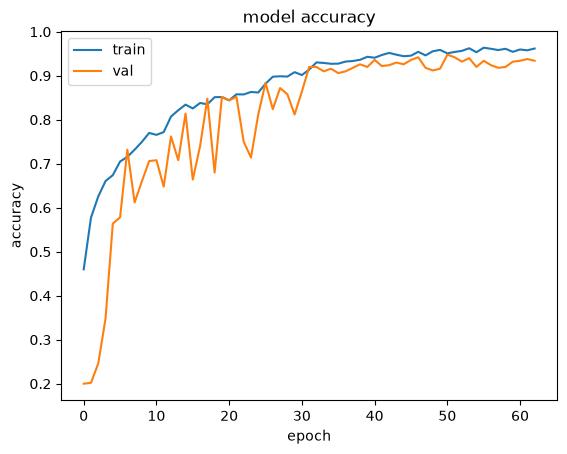

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

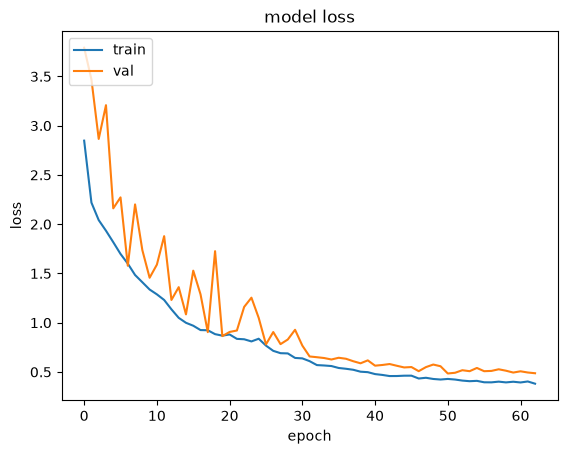

In [11]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [12]:

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter( y=model_fit.history['val_loss'], name="val_loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['loss'], name="loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['val_accuracy'], name="val_accuracy"),
    secondary_y=True)

fig.add_trace(
    go.Scatter( y=model_fit.history['accuracy'], name="accuracy"),
    secondary_y=True)

# Add figure title
fig.update_layout(
    title_text="Loss/Accuracy of Conv2D Model")

# Set x-axis title
fig.update_xaxes(title_text="Number of Epochs")

# Set y-axes titles
fig.update_yaxes(title_text="<b>primary</b> Loss", secondary_y=False)
fig.update_yaxes(title_text="<b>secondary</b> Accuracy", secondary_y=True)

fig.show()

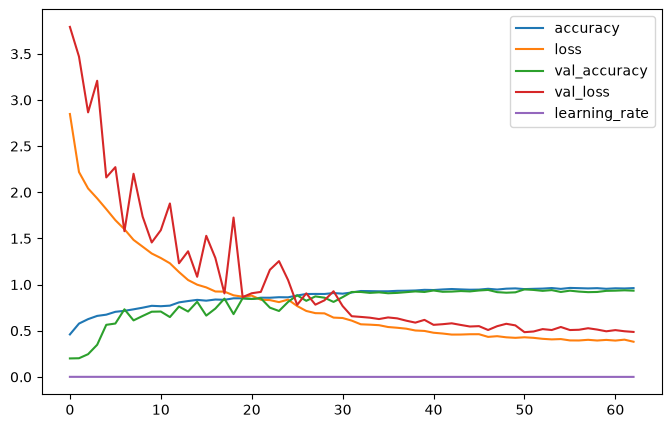

In [13]:
pd.DataFrame(model_fit.history).plot(figsize=(8,5))
plt.show()

In [14]:
model.summary() #Detail of model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,273,809 (149.82 MB)

 Trainable params: 13,090,693 (49.94 MB)

 Non-trainable params: 1,728 (6.75 KB)

 Optimizer params: 26,181,388 (99.87 MB)

In [15]:
plot_model(model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [16]:
validation_dataset.class_indices

{'Cat': 0, 'Dog': 1, 'Elephant': 2, 'Horse': 3, 'Chicken': 4}

In [17]:
from tensorflow.keras.models import load_model

# This loads the absolute peak 99.37% brain that the checkpoint saved!
model = load_model('models/CNN_predict_model.h5')
print("Successfully loaded the peak 99% model!")


Successfully loaded the peak 99% model!


In [18]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

test_dir = 'Dataset/test/'
animal_folders = ['Cat', 'Dog', 'Elephant', 'Horse', 'Chicken']
animal_names = ['Cat 🐈', 'Dog 🐶', 'Elephant 🐘', 'Horse 🐎', 'Chicken 🐔']

for folder in animal_folders:
    dir_path = os.path.join(test_dir, folder)
    if not os.path.exists(dir_path):
        continue
        
    print(f"\n--- Testing images in {dir_path} ---")
    
    counts = [0, 0, 0, 0, 0]
    
    for i in os.listdir(dir_path):
        if i.startswith('.'): continue
            
        img = image.load_img(os.path.join(dir_path, i), target_size=(256, 256, 3))
        
        X = image.img_to_array(img)
        X = X / 255.0
        X = np.expand_dims(X, axis=0)
        
        val = model.predict(X, verbose=0) # verbose=0 to hide progress bars and keep output clean
        
        best_guess = np.argmax(val)
        counts[best_guess] += 1
        
    print(f'Results for {folder}: Cat={counts[0]}, Dog={counts[1]}, Elephant={counts[2]}, Horse={counts[3]}, Chicken={counts[4]}')



--- Testing images in Dataset/test/Cat ---
Results for Cat: Cat=73, Dog=5, Elephant=1, Horse=0, Chicken=1

--- Testing images in Dataset/test/Dog ---
Results for Dog: Cat=11, Dog=60, Elephant=5, Horse=2, Chicken=2

--- Testing images in Dataset/test/Elephant ---
Results for Elephant: Cat=4, Dog=8, Elephant=68, Horse=0, Chicken=0

--- Testing images in Dataset/test/Horse ---
Results for Horse: Cat=0, Dog=0, Elephant=2, Horse=75, Chicken=3

--- Testing images in Dataset/test/Chicken ---
Results for Chicken: Cat=4, Dog=4, Elephant=3, Horse=2, Chicken=67


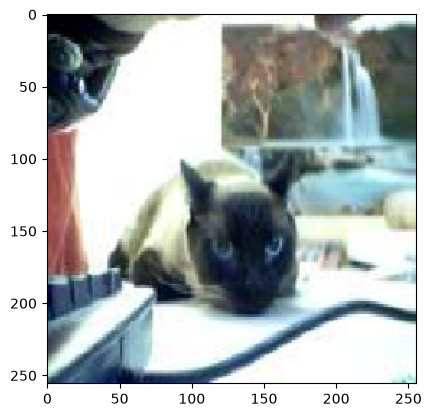

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Prediction: This is Cat (Confidence: 83.13%)


In [19]:
# path of image that you want to predict correct class
path = 'Dataset/test/mixed/5.JPG'
img = image.load_img(path, target_size=(256, 256, 3))
plt.imshow(img)
plt.show()
    
X = image.img_to_array(img)
X = X / 255.0
X = np.expand_dims(X, axis=0)

val = model.predict(X)

animal_names = ['Cat', 'Dog', 'Elephant', 'Horse', 'Chicken']
best_guess = np.argmax(val)
picture = animal_names[best_guess]
        
print(f'Prediction: This is {picture} (Confidence: {val[0][best_guess] * 100:.2f}%)')


In [20]:
# from tensorflow.keras.models import load_model
# new_model = load_model('models/CNN_predict_model.h5')

# Save the model and overwrite the old one if it exists
# model.save('models/CNN_predict_model.h5')


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,092,423 (49.94 MB)

 Trainable params: 13,090,693 (49.94 MB)

 Non-trainable params: 1,728 (6.75 KB)

 Optimizer params: 2 (12.00 B)